# Analisis Perpindahan Penumpang Antarhalte (data kode B)

In [56]:
import time
import tracemalloc
from collections import deque
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
DATA = Path('/kaggle/input/datasets/frankyrayms/tk1-anum-perpindahan-penumpang')
HASIL = Path('hasil')
HASIL.mkdir(exist_ok=True)

N_LIST = [16, 32, 64, 128, 256, 512]
TOL_BARIS = 1e-12 # toleransi untuk |jumlah baris - 1|

np.set_printoptions(precision=4, suppress=True, linewidth=120)

## i. Validasi Data

In [58]:
def baca_T(N: int) -> np.ndarray:
    return np.loadtxt(DATA / f'T_{N}.csv', delimiter=',')

In [59]:
T_all = {N: baca_T(N) for N in N_LIST}

In [60]:
{N: T.shape for N, T in T_all.items()}

{16: (16, 16),
 32: (32, 32),
 64: (64, 64),
 128: (128, 128),
 256: (256, 256),
 512: (512, 512)}

In [61]:
T_all[16][:6, :6]

array([[0.925 , 0.06  , 0.015 , 0.    , 0.    , 0.    ],
       [0.0651, 0.8599, 0.06  , 0.015 , 0.    , 0.    ],
       [0.    , 0.0775, 0.8475, 0.06  , 0.015 , 0.    ],
       [0.    , 0.    , 0.0797, 0.8453, 0.06  , 0.015 ],
       [0.    , 0.    , 0.    , 0.0827, 0.8423, 0.06  ],
       [0.    , 0.    , 0.    , 0.    , 0.086 , 0.8392]])

In [62]:
def bfs_jumlah_dikunjungi(T: np.ndarray, balik: bool = False) -> int:
    N = T.shape[0]
    dikunjungi = np.zeros(N, dtype=bool)
    dikunjungi[0] = True
    antrean = deque([0])
    while antrean:
        u = antrean.popleft()
        # graf asli: tetangga dari baris u; graf dibalik: dari kolom u
        if balik:
            tetangga = np.nonzero(T[:, u] > 0)[0]
        else:
            tetangga = np.nonzero(T[u, :] > 0)[0]
        for v in tetangga:
            if not dikunjungi[v]:
                dikunjungi[v] = True
                antrean.append(v)
    return int(dikunjungi.sum())

In [63]:
def validasi_T(T: np.ndarray, N: int, tol: float = TOL_BARIS) -> dict:
    hasil = {'N': N}
    hasil['dimensi_ok'] = T.shape == (N, N)
    hasil['hingga'] = bool(np.all(np.isfinite(T)))
    if not (hasil['dimensi_ok'] and hasil['hingga']):
        hasil['valid'] = False
        return hasil

    hasil['nonnegatif'] = bool(T.min() >= 0)
    hasil['galat_baris_maks'] = float(np.max(np.abs(T.sum(axis=1) - 1)))
    hasil['baris_ok'] = hasil['galat_baris_maks'] <= tol
    # terhubung kuat, semua halte tercapai dari halte 1 DAN halte 1 tercapai dari semua halte
    hasil['irreducible'] = (bfs_jumlah_dikunjungi(T) == N
                            and bfs_jumlah_dikunjungi(T, balik=True) == N)
    hasil['aperiodik'] = bool(np.any(np.diag(T) > 0))
    hasil['min_diag'] = float(np.diag(T).min())
    # peluang pindah terkecil yang masih positif; sangat kecil = rantai "hampir terputus"
    luar_diag = T - np.diag(np.diag(T))
    hasil['min_taknol_luar_diag'] = float(luar_diag[luar_diag > 0].min()) if np.any(luar_diag > 0) else 0.0

    nnz = np.count_nonzero(T, axis=1)
    hasil['nnz_per_baris'] = f'{nnz.min()}-{nnz.max()}'
    i, j = np.nonzero(T)
    hasil['offset_taknol'] = str(sorted(set((j - i).tolist()))) # nilai j - i dari elemen tak-nol

    hasil['valid'] = hasil['nonnegatif'] and hasil['baris_ok'] and hasil['irreducible']
    return hasil

### i.a Uji fungsi validasi pada matriks 3 × 3

In [64]:
T_uji = {
    'valid':         np.array([[0.50, 0.50, 0.00], [0.25, 0.50, 0.25], [0.00, 0.50, 0.50]]),
    'ada_negatif':   np.array([[1.20, -0.20, 0.00], [0.25, 0.50, 0.25], [0.00, 0.50, 0.50]]),
    'baris_tidak_1': np.array([[0.50, 0.40, 0.00], [0.25, 0.50, 0.25], [0.00, 0.50, 0.50]]),
    'reducible':     np.array([[1.00, 0.00, 0.00], [0.25, 0.50, 0.25], [0.00, 0.50, 0.50]]),  # halte 1 menyerap
}
df_uji_validasi = pd.DataFrame([{'kasus': k, **validasi_T(T, 3)} for k, T in T_uji.items()])
df_uji_validasi.to_csv(HASIL / 'uji_validasi.csv', index=False)
df_uji_validasi

,kasus,N,dimensi_ok,hingga,nonnegatif,galat_baris_maks,baris_ok,irreducible,aperiodik,min_diag,min_taknol_luar_diag,nnz_per_baris,offset_taknol,valid
0,valid,3,True,True,True,0.0,True,True,True,0.5,0.25,2-3,"[-1, 0, 1]",True
1,ada_negatif,3,True,True,False,0.0,True,False,True,0.5,0.25,2-3,"[-1, 0, 1]",False
2,baris_tidak_1,3,True,True,True,0.1,False,True,True,0.5,0.25,2-3,"[-1, 0, 1]",False
3,reducible,3,True,True,True,0.0,True,False,True,0.5,0.25,1-3,"[-1, 0, 1]",False


In [65]:
harapan = {'valid': True, 'ada_negatif': False, 'baris_tidak_1': False, 'reducible': False}
print('Semua keputusan sesuai harapan:',
      all(df_uji_validasi.set_index('kasus')['valid'][k] == v for k, v in harapan.items()))

Semua keputusan sesuai harapan: True


### i.b Validasi seluruh data

In [66]:
df_validasi = pd.DataFrame([validasi_T(T_all[N], N) for N in N_LIST])
df_validasi.to_csv(HASIL / 'validasi.csv', index=False)
df_validasi

,N,dimensi_ok,hingga,nonnegatif,galat_baris_maks,baris_ok,irreducible,aperiodik,min_diag,min_taknol_luar_diag,nnz_per_baris,offset_taknol,valid
0,16,True,True,True,1.110223e-16,True,True,True,0.835,1.442425e-02,2-4,"[-1, 0, 1, 2]",True
1,32,True,True,True,2.220446e-16,True,True,True,0.835,1.467299e-02,2-4,"[-1, 0, 1, 2]",True
2,64,True,True,True,2.220446e-16,True,True,True,0.835,1.483285e-02,2-4,"[-1, 0, 1, 2]",True
3,128,True,True,True,2.220446e-16,True,True,True,0.835,1.491620e-02,2-4,"[-1, 0, 1, 2]",True
4,256,True,True,True,2.220446e-16,True,True,True,0.835,1.495813e-08,2-4,"[-1, 0, 1, 2]",True
5,512,True,True,True,2.220446e-16,True,True,True,0.835,1.497908e-02,2-4,"[-1, 0, 1, 2]",True


In [67]:
# N = 256: lokasi peluang pindah yang sangat kecil
T = T_all[256]
for i in range(125, 132): # halte 126..132
    kolom = np.nonzero(T[i])[0]
    print(f'halte {i + 1}:', {int(j) + 1: float(f'{T[i, j]:.4g}') for j in kolom})
print('total peluang lintas halte 1-128 -> 129-256:', T[:128, 128:].sum())
print('total peluang lintas halte 129-256 -> 1-128:', T[128:, :128].sum())

halte 126: {125: 0.08998, 126: 0.8351, 127: 0.05992, 128: 0.01496}
halte 127: {126: 0.08998, 127: 0.8501, 128: 0.05992, 129: 1.496e-08}
halte 128: {127: 0.075, 128: 0.925, 129: 5.992e-08, 130: 1.496e-08}
halte 129: {128: 8.998e-08, 129: 0.9251, 130: 0.05992, 131: 0.01496}
halte 130: {129: 0.07498, 130: 0.8501, 131: 0.05992, 132: 0.01496}
halte 131: {130: 0.08998, 131: 0.8351, 132: 0.05992, 133: 0.01496}
halte 132: {131: 0.08998, 132: 0.8351, 133: 0.05992, 134: 0.01496}
total peluang lintas halte 1-128 -> 129-256: 8.98324063775423e-08
total peluang lintas halte 129-256 -> 1-128: 8.99790602862457e-08


Semua matriks valid. Untuk $N = 256$, perpindahan antara halte 128 dan 129 hanya berorde $10^{-8}$: rantai tetap
irreducible tetapi hampir terpecah menjadi dua blok.

## ii. Formulasi dan Penanganan Singularitas

In [68]:
# A = I - T^T singular: jumlah semua baris A (vektor 1^T A) adalah nol
A16 = np.eye(16) - T_all[16].T
print('max |1^T A| =', np.max(np.abs(A16.sum(axis=0))))

max |1^T A| = 1.249000902703301e-16


In [69]:
def bentuk_B_dense(T: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    N = T.shape[0]
    B = np.eye(N) - T.T          # A = I - T^T
    B[0, :] = 0.0                # baris 1 diganti [1 0 ... 0]
    B[0, 0] = 1.0
    b = np.zeros(N)
    b[0] = 1.0
    return B, b

In [70]:
B16, b16 = bentuk_B_dense(T_all[16])
B16[:6, :6]

array([[ 1.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ],
       [-0.06  ,  0.1401, -0.0775,  0.    ,  0.    ,  0.    ],
       [-0.015 , -0.06  ,  0.1525, -0.0797,  0.    ,  0.    ],
       [ 0.    , -0.015 , -0.06  ,  0.1547, -0.0827,  0.    ],
       [ 0.    ,  0.    , -0.015 , -0.06  ,  0.1577, -0.086 ],
       [ 0.    ,  0.    ,  0.    , -0.015 , -0.06  ,  0.1608]])

In [71]:
b16

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

## iii. Identifikasi Struktur Matriks

In [72]:
def deteksi_bandwidth(M: np.ndarray) -> tuple[int, int]:
    '''Menentukan bandwidth dari posisi elemen tak-nol.

    Input : M (N x N).
    Output: p = maks(i - j) (lower), q = maks(j - i) (upper).
    '''
    i, j = np.nonzero(M)
    p = max(0, int(np.max(i - j)))
    q = max(0, int(np.max(j - i)))
    return p, q

In [73]:
# p, q dari A dan dari B dibandingkan: penggantian baris 1 tidak boleh mengubah band
baris = []
for N in N_LIST:
    T = T_all[N]
    B, _ = bentuk_B_dense(T)
    p_A, q_A = deteksi_bandwidth(np.eye(N) - T.T)
    p, q = deteksi_bandwidth(B)
    baris.append({'N': N, 'p_A': p_A, 'q_A': q_A, 'p': p, 'q': q})
df_band = pd.DataFrame(baris)
df_band

,N,p_A,q_A,p,q
0,16,2,1,2,1
1,32,2,1,2,1
2,64,2,1,2,1
3,128,2,1,2,1
4,256,2,1,2,1
5,512,2,1,2,1


In [74]:
# Kebutuhan memori float64: dense N^2, band (p+q+1)N, band + ruang fill-in pivoting (2p+q+1)N
p, q = int(df_band['p'].iloc[0]), int(df_band['q'].iloc[0])
df_storage = pd.DataFrame({
    'N': N_LIST,
    'dense_byte': [8 * N * N for N in N_LIST],
    'band_byte': [8 * (p + q + 1) * N for N in N_LIST],
    'band_pivot_byte': [8 * (2 * p + q + 1) * N for N in N_LIST],
})
df_storage['rasio_dense_per_band_pivot'] = df_storage['dense_byte'] / df_storage['band_pivot_byte']
df_storage.to_csv(HASIL / 'storage.csv', index=False)
df_storage

,N,dense_byte,band_byte,band_pivot_byte,rasio_dense_per_band_pivot
0,16,2048,512,768,2.666667
1,32,8192,1024,1536,5.333333
2,64,32768,2048,3072,10.666667
3,128,131072,4096,6144,21.333333
4,256,524288,8192,12288,42.666667
5,512,2097152,16384,24576,85.333333


$B$ memiliki $p = 2$ dan $q = 1$ untuk semua $N$, sama dengan $A$.

## iv. Implementasi Solver

### iv.a LU dense dengan partial pivoting

In [75]:
def lu_dense(B: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    LU = B.astype(float).copy()
    N = LU.shape[0]
    perm = np.arange(N)
    for k in range(N - 1):
        # pivot: elemen dengan nilai mutlak terbesar di kolom k, baris k..N-1
        r = k + int(np.argmax(np.abs(LU[k:, k])))
        if LU[r, k] == 0.0:
            raise ValueError(f'B singular: kolom {k} tidak punya pivot tak-nol')
        if r != k:
            LU[[k, r], :] = LU[[r, k], :] # tukar seluruh baris, termasuk multiplier lama
            perm[[k, r]] = perm[[r, k]]
        # multiplier l_ik disimpan di tempat elemen yang dieliminasi
        LU[k + 1:, k] /= LU[k, k]
        # baris i dikurangi l_ik * baris k (kolom k+1 ke kanan)
        LU[k + 1:, k + 1:] -= np.outer(LU[k + 1:, k], LU[k, k + 1:])
    if LU[N - 1, N - 1] == 0.0:
        raise ValueError('B singular: pivot terakhir nol')
    return LU, perm

In [76]:
def solve_lu(LU: np.ndarray, perm: np.ndarray, b: np.ndarray) -> np.ndarray:
    N = LU.shape[0]
    y = b[perm].astype(float) # Pb
    for i in range(1, N): # substitusi maju Ly = Pb (diagonal L = 1)
        y[i] -= np.dot(LU[i, :i], y[:i])
    z = np.zeros(N)
    for i in range(N - 1, -1, -1): # substitusi mundur Uz = y
        z[i] = (y[i] - np.dot(LU[i, i + 1:], z[i + 1:])) / LU[i, i]
    return z

In [77]:
def pisah_LU(LU: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    L = np.tril(LU, -1) + np.eye(LU.shape[0])
    U = np.triu(LU)
    return L, U

In [78]:
def norma2(v: np.ndarray) -> float:
    return float(np.sqrt(np.sum(v * v)))


def galat_pi(T: np.ndarray, pi: np.ndarray) -> tuple[float, float]:
    r = norma2(T.T @ pi - pi)
    e_norm = abs(float(np.sum(pi)) - 1.0)
    return r, e_norm

In [79]:
def steady_state_dense(T: np.ndarray) -> np.ndarray:
    B, b = bentuk_B_dense(T)
    LU, perm = lu_dense(B)
    z = solve_lu(LU, perm, b)
    return z / np.sum(z)

#### Uji 1: matriks 3 × 3 yang dihitung manual (memaksa dua kali tukar baris)

In [80]:
B_uji = np.array([[2., 1., 1.], [4., 3., 3.], [8., 7., 9.]])
b_uji = np.array([3., 7., 19.])           # = B_uji @ [1, -1, 2]

LU_uji, perm_uji = lu_dense(B_uji)
L_uji, U_uji = pisah_LU(LU_uji)
L_uji, U_uji, perm_uji

(array([[1.    , 0.    , 0.    ],
        [0.25  , 1.    , 0.    ],
        [0.5   , 0.6667, 1.    ]]),
 array([[ 8.    ,  7.    ,  9.    ],
        [ 0.    , -0.75  , -1.25  ],
        [ 0.    ,  0.    , -0.6667]]),
 array([2, 0, 1]))

In [81]:
# Hasil hitungan tangan
L_tangan = np.array([[1, 0, 0], [0.25, 1, 0], [0.5, 2 / 3, 1]])
U_tangan = np.array([[8, 7, 9], [0, -0.75, -1.25], [0, 0, -2 / 3]])
z_uji = solve_lu(LU_uji, perm_uji, b_uji)

print('L sama dengan hitungan tangan    :', np.allclose(L_uji, L_tangan, atol=1e-14))
print('U sama dengan hitungan tangan    :', np.allclose(U_uji, U_tangan, atol=1e-14))
print('perm sama dengan hitungan tangan :', np.array_equal(perm_uji, [2, 0, 1]))
print('max |PB - LU|                    :', np.max(np.abs(B_uji[perm_uji] - L_uji @ U_uji)))
print('z =', z_uji, ' (harapan [1, -1, 2])')

L sama dengan hitungan tangan    : True
U sama dengan hitungan tangan    : True
perm sama dengan hitungan tangan : True
max |PB - LU|                    : 0.0
z = [ 1. -1.  2.]  (harapan [1, -1, 2])


#### Uji 2: pivot diagonal nol dan matriks singular

In [82]:
B_nol = np.array([[0., 2., 1., 0.],
                  [1., 1., 0., 0.],
                  [0., 1., 3., 1.],
                  [0., 0., 1., 2.]])
x_benar = np.array([1., 2., 3., 4.])
LU_nol, perm_nol = lu_dense(B_nol)
z_nol = solve_lu(LU_nol, perm_nol, B_nol @ x_benar)
print('perm =', perm_nol)
print('z    =', z_nol, ' max galat =', np.max(np.abs(z_nol - x_benar)))

perm = [1 0 2 3]
z    = [1. 2. 3. 4.]  max galat = 4.440892098500626e-16


In [83]:
try:
    lu_dense(np.array([[1., 2.], [2., 4.]]))
    print('GAGAL: matriks singular tidak terdeteksi')
except ValueError as e:
    print('Terdeteksi:', e)

Terdeteksi: B singular: pivot terakhir nol


#### Uji 3: rantai Markov 3 × 3 dengan $\pi = [0{,}25,\ 0{,}5,\ 0{,}25]$

In [84]:
pi_uji = steady_state_dense(T_uji['valid'])
print('pi =', pi_uji, ' max galat =', np.max(np.abs(pi_uji - [0.25, 0.5, 0.25])))
print('r, e_norm =', galat_pi(T_uji['valid'], pi_uji))

pi = [0.25 0.5  0.25]  max galat = 0.0
r, e_norm = (0.0, 0.0)


#### Solver dense pada seluruh data

In [85]:
# baris_berpindah = banyak baris yang posisinya diubah oleh P (0 = pivoting tidak pernah menukar)
pi_dense = {}
baris = []
for N in N_LIST:
    B, b = bentuk_B_dense(T_all[N])
    LU, perm = lu_dense(B)
    L, U = pisah_LU(LU)
    pi_dense[N] = steady_state_dense(T_all[N])
    r, e_norm = galat_pi(T_all[N], pi_dense[N])
    baris.append({
        'N': N,
        'baris_berpindah': int(np.count_nonzero(perm != np.arange(N))),
        'max_abs_PB_min_LU': float(np.max(np.abs(B[perm] - L @ U))),
        'r': r,
        'e_norm': e_norm,
        'pi_min': float(pi_dense[N].min()),
        'pi_maks': float(pi_dense[N].max()),
    })
df_dense = pd.DataFrame(baris)
df_dense.to_csv(HASIL / 'akurasi_dense.csv', index=False)
df_dense

,N,baris_berpindah,max_abs_PB_min_LU,r,e_norm,pi_min,pi_maks
0,16,0,1.387779e-17,1.551584e-17,0.0,0.039016,0.095963
1,32,0,6.938894e-18,1.298148e-17,0.0,0.019570,0.048136
2,64,0,1.387779e-17,9.658532e-18,0.0,0.009800,0.024103
3,128,0,1.387779e-17,5.946332e-18,0.0,0.004903,0.012060
4,256,0,1.387779e-17,3.854640e-18,0.0,0.002452,0.006032
5,512,0,1.387779e-17,3.208945e-18,0.0,0.001226,0.003017


#### [VERIFIKASI] Pembanding `np.linalg.solve`

In [86]:
# [VERIFIKASI] np.linalg dipakai hanya di tiap sel [VERIFIKASI]
baris = []
for N in N_LIST:
    B, b = bentuk_B_dense(T_all[N])
    z_ref = np.linalg.solve(B, b)
    pi_ref = z_ref / np.sum(z_ref)
    baris.append({'N': N, 'max_abs_selisih_dense_vs_numpy': float(np.max(np.abs(pi_dense[N] - pi_ref)))})
df_verif_dense = pd.DataFrame(baris)
df_verif_dense.to_csv(HASIL / 'verifikasi_dense_numpy.csv', index=False)
df_verif_dense

,N,max_abs_selisih_dense_vs_numpy
0,16,1.249001e-16
1,32,1.318390e-16
2,64,2.602085e-16
3,128,1.353084e-16
4,256,6.577586e-13
5,512,4.050579e-16


Seluruh uji kecil lolos. Pada data asli pivoting tidak pernah menukar baris, $r \le 2 \times 10^{-17}$, dan
selisih dengan `np.linalg.solve` berorde $10^{-16}$, kecuali $N = 256$ (orde $10^{-13}$, lihat i.b).

### iv.b Solver banded dengan partial pivoting

In [87]:
def deteksi_bandwidth_T(T: np.ndarray) -> tuple[int, int]:
    i, j = np.nonzero(T)
    pakai = j >= 1
    p = max(0, int(np.max(j[pakai] - i[pakai])))
    q = max(0, int(np.max(i[pakai] - j[pakai])))
    return p, q

In [88]:
def bentuk_B_band(T: np.ndarray, p: int, q: int) -> tuple[np.ndarray, np.ndarray]:
    N = T.shape[0]
    d = p + q # baris AB tempat diagonal utama
    AB = np.zeros((2 * p + q + 1, N))
    AB[d, 0] = 1.0 # baris 1 B = [1 0 ... 0]
    for i in range(1, N):
        for j in range(max(0, i - p), min(N - 1, i + q) + 1):
            AB[d + i - j, j] = (1.0 if i == j else 0.0) - T[j, i]
    b = np.zeros(N)
    b[0] = 1.0
    return AB, b

In [89]:
def lu_band(AB: np.ndarray, p: int, q: int) -> tuple[np.ndarray, np.ndarray]:
    AB = AB.copy()
    d = p + q
    N = AB.shape[1]
    piv = np.zeros(N, dtype=int)
    for k in range(N):
        i_maks = min(N - 1, k + p) 
        j_maks = min(N - 1, k + p + q) 
        r = k + int(np.argmax(np.abs(AB[d:d + i_maks - k + 1, k])))
        if AB[d + r - k, k] == 0.0:
            raise ValueError(f'B singular: kolom {k} tidak punya pivot tak-nol')
        piv[k] = r
        js = np.arange(k, j_maks + 1)
        if r != k:
            sementara = AB[d + k - js, js]
            AB[d + k - js, js] = AB[d + r - js, js]
            AB[d + r - js, js] = sementara
        js = js[1:]
        for i in range(k + 1, i_maks + 1):
            AB[d + i - k, k] /= AB[d, k]
            AB[d + i - js, js] -= AB[d + i - k, k] * AB[d + k - js, js]
    return AB, piv

In [90]:
def solve_band(AB: np.ndarray, piv: np.ndarray, p: int, q: int, b: np.ndarray) -> np.ndarray:
    d = p + q
    N = AB.shape[1]
    y = b.astype(float).copy()
    for k in range(N):
        r = piv[k]
        if r != k:
            y[k], y[r] = y[r], y[k]
        for i in range(k + 1, min(N - 1, k + p) + 1):
            y[i] -= AB[d + i - k, k] * y[k]
    z = np.zeros(N)
    for i in range(N - 1, -1, -1): 
        js = np.arange(i + 1, min(N - 1, i + p + q) + 1)
        z[i] = (y[i] - np.dot(AB[d + i - js, js], z[js])) / AB[d, i]
    return z

In [91]:
def steady_state_band(T: np.ndarray, p: int, q: int) -> np.ndarray:
    AB, b = bentuk_B_band(T, p, q)
    AB_lu, piv = lu_band(AB, p, q)
    z = solve_band(AB_lu, piv, p, q, b)
    return z / np.sum(z)

In [92]:
def dense_ke_band(M: np.ndarray, p: int, q: int) -> np.ndarray:
    d = p + q
    N = M.shape[0]
    AB = np.zeros((2 * p + q + 1, N))
    for i in range(N):
        for j in range(max(0, i - p), min(N - 1, i + q) + 1):
            AB[d + i - j, j] = M[i, j]
    return AB


def band_ke_dense(AB: np.ndarray, p: int, q: int, offset_maks: int) -> np.ndarray:
    d = p + q
    N = AB.shape[1]
    M = np.zeros((N, N))
    for i in range(N):
        for j in range(max(0, i - p), min(N - 1, i + offset_maks) + 1):
            M[i, j] = AB[d + i - j, j]
    return M


def piv_ke_perm(piv: np.ndarray) -> np.ndarray:
    perm = np.arange(len(piv))
    for k, r in enumerate(piv):
        perm[[k, r]] = perm[[r, k]]
    return perm

#### Uji 1: pembentukan band langsung dari T sama dengan B dense

In [93]:
baris = []
for N in N_LIST:
    p, q = deteksi_bandwidth_T(T_all[N])
    AB, b = bentuk_B_band(T_all[N], p, q)
    B, _ = bentuk_B_dense(T_all[N])
    baris.append({'N': N, 'p': p, 'q': q, 'shape_AB': AB.shape,
                  'B_band_sama_B_dense': bool(np.array_equal(band_ke_dense(AB, p, q, q), B))})
pd.DataFrame(baris)

,N,p,q,shape_AB,B_band_sama_B_dense
0,16,2,1,"(6, 16)",True
1,32,2,1,"(6, 32)",True
2,64,2,1,"(6, 64)",True
3,128,2,1,"(6, 128)",True
4,256,2,1,"(6, 256)",True
5,512,2,1,"(6, 512)",True


#### Uji 2: matriks 3 × 3 dari iv.a (p = q = 2), harus sama dengan hitungan tangan

In [94]:
p_u, q_u = 2, 2
AB_u_lu, piv_u = lu_band(dense_ke_band(B_uji, p_u, q_u), p_u, q_u)
U_band = np.triu(band_ke_dense(AB_u_lu, p_u, q_u, p_u + q_u))
print('piv =', piv_u, '-> perm =', piv_ke_perm(piv_u), ' (harapan perm [2, 0, 1])')
print('U sama dengan hitungan tangan :', np.allclose(U_band, U_tangan, atol=1e-14))
print('z =', solve_band(AB_u_lu, piv_u, p_u, q_u, b_uji), ' (harapan [1, -1, 2])')

piv = [2 2 2] -> perm = [2 0 1]  (harapan perm [2, 0, 1])
U sama dengan hitungan tangan : True
z = [ 1. -1.  2.]  (harapan [1, -1, 2])


#### Uji 3: matriks band 8 × 8 (p = 2, q = 1) yang memaksa tukar baris dan fill-in

In [95]:
rng = np.random.default_rng(0)
N_b, p_b, q_b = 8, 2, 1
B_b = np.zeros((N_b, N_b))
for i in range(N_b):
    for j in range(max(0, i - p_b), min(N_b - 1, i + q_b) + 1):
        B_b[i, j] = rng.uniform(1, 2)
B_b[np.arange(N_b), np.arange(N_b)] *= 0.01
x_b = np.arange(1., N_b + 1)

AB_b_lu, piv_b = lu_band(dense_ke_band(B_b, p_b, q_b), p_b, q_b)
z_b = solve_band(AB_b_lu, piv_b, p_b, q_b, B_b @ x_b)
LU_d, perm_d = lu_dense(B_b)
L_d, U_d = pisah_LU(LU_d)

print('piv                      :', piv_b, ' tukar baris =', int(np.count_nonzero(piv_b != np.arange(N_b))))
print('fill-in (tak-nol di p baris teratas AB):', int(np.count_nonzero(AB_b_lu[:p_b])))
print('perm sama dengan dense   :', np.array_equal(piv_ke_perm(piv_b), perm_d))
print('U sama dengan dense      :', np.allclose(np.triu(band_ke_dense(AB_b_lu, p_b, q_b, p_b + q_b)), U_d, atol=1e-12))
print('U dense melebar sampai offset', deteksi_bandwidth(U_d)[1], '(batas p + q =', p_b + q_b, ')')
print('max |z - x|              :', np.max(np.abs(z_b - x_b)))

piv                      : [2 3 3 4 5 6 7 7]  tukar baris = 7
fill-in (tak-nol di p baris teratas AB): 8
perm sama dengan dense   : True
U sama dengan dense      : True
U dense melebar sampai offset 3 (batas p + q = 3 )
max |z - x|              : 5.329070518200751e-15


#### Uji 4: matriks singular dan rantai Markov 3 × 3

In [96]:
try:
    lu_band(dense_ke_band(np.array([[1., 2.], [2., 4.]]), 1, 1), 1, 1)
    print('GAGAL: matriks singular tidak terdeteksi')
except ValueError as e:
    print('Terdeteksi:', e)

Terdeteksi: B singular: kolom 1 tidak punya pivot tak-nol


In [97]:
pi_uji_band = steady_state_band(T_uji['valid'], *deteksi_bandwidth_T(T_uji['valid']))
print('pi =', pi_uji_band, ' max galat =', np.max(np.abs(pi_uji_band - [0.25, 0.5, 0.25])))

pi = [0.25 0.5  0.25]  max galat = 0.0


#### Solver banded pada seluruh data

In [98]:
pi_band = {}
baris = []
for N in N_LIST:
    p, q = deteksi_bandwidth_T(T_all[N])
    AB, b = bentuk_B_band(T_all[N], p, q)
    AB_lu, piv = lu_band(AB, p, q)
    z = solve_band(AB_lu, piv, p, q, b)
    pi_band[N] = z / np.sum(z)
    r, e_norm = galat_pi(T_all[N], pi_band[N])
    baris.append({
        'N': N,
        'tukar_baris': int(np.count_nonzero(piv != np.arange(N))),
        'r': r,
        'e_norm': e_norm,
        'max_abs_selisih_band_vs_dense': float(np.max(np.abs(pi_band[N] - pi_dense[N]))),
    })
df_band_hasil = pd.DataFrame(baris)
df_band_hasil.to_csv(HASIL / 'akurasi_band.csv', index=False)
df_band_hasil

,N,tukar_baris,r,e_norm,max_abs_selisih_band_vs_dense
0,16,0,1.551584e-17,0.0,0.0
1,32,0,1.298148e-17,0.0,0.0
2,64,0,9.658532e-18,0.0,0.0
3,128,0,5.946332e-18,0.0,0.0
4,256,0,3.854640e-18,0.0,0.0
5,512,0,3.208945e-18,0.0,0.0


#### [VERIFIKASI] Pembanding `np.linalg.solve`

In [99]:
baris = []
for N in N_LIST:
    B, b = bentuk_B_dense(T_all[N])
    z_ref = np.linalg.solve(B, b)
    pi_ref = z_ref / np.sum(z_ref)
    baris.append({'N': N, 'max_abs_selisih_band_vs_numpy': float(np.max(np.abs(pi_band[N] - pi_ref)))})
df_verif_band = pd.DataFrame(baris)
df_verif_band.to_csv(HASIL / 'verifikasi_band_numpy.csv', index=False)
df_verif_band

,N,max_abs_selisih_band_vs_numpy
0,16,1.249001e-16
1,32,1.318390e-16
2,64,2.602085e-16
3,128,1.353084e-16
4,256,6.577586e-13
5,512,4.050579e-16


Seluruh uji kecil lolos, termasuk kasus dengan tukar baris dan fill-in. Pada data asli, $\pi$ dari solver banded
identik dengan solver dense (selisih 0) dan selisihnya dengan `np.linalg.solve` sama dengan solver dense.

## v. Eksperimen Kinerja

In [100]:
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
WARNA_DENSE = '#2563eb'
WARNA_BAND = '#d97706'
WARNA_REF = '#9ca3af'

ULANG = 15   # ulangan per pengukuran waktu; yang dilaporkan nilai minimum

In [101]:
def ukur_waktu(fungsi, ulang: int = ULANG) -> float:
    fungsi()
    waktu = []
    for _ in range(ulang):
        t0 = time.perf_counter()
        fungsi()
        waktu.append(time.perf_counter() - t0)
    return float(np.min(waktu))


def ukur_peak(fungsi):
    tracemalloc.start()
    hasil = fungsi()
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return peak, hasil

In [102]:
def jalankan_dense(B: np.ndarray, b: np.ndarray):
    LU, perm = lu_dense(B)
    z = solve_lu(LU, perm, b)
    return z / np.sum(z), LU, perm


def jalankan_band(AB: np.ndarray, b: np.ndarray, p: int, q: int):
    AB_lu, piv = lu_band(AB, p, q)
    z = solve_band(AB_lu, piv, p, q, b)
    return z / np.sum(z), AB_lu, piv

In [103]:
def benchmark(T: np.ndarray, ulang: int = ULANG) -> dict:
    N = T.shape[0]
    hasil = {'N': N}

    hasil['prep_dense_s'] = ukur_waktu(lambda: bentuk_B_dense(T), ulang)
    B, b = bentuk_B_dense(T)
    hasil['solver_dense_s'] = ukur_waktu(lambda: jalankan_dense(B, b), ulang)
    peak, (pi, LU, perm) = ukur_peak(lambda: jalankan_dense(B, b))
    hasil['peak_dense_byte'] = peak
    
    hasil['nbytes_dense'] = B.nbytes + b.nbytes + LU.nbytes + perm.nbytes + pi.nbytes

    hasil['deteksi_band_s'] = ukur_waktu(lambda: deteksi_bandwidth_T(T), ulang)
    p, q = deteksi_bandwidth_T(T)
    hasil['ekstraksi_band_s'] = ukur_waktu(lambda: bentuk_B_band(T, p, q), ulang)
    AB, b = bentuk_B_band(T, p, q)
    hasil['solver_band_s'] = ukur_waktu(lambda: jalankan_band(AB, b, p, q), ulang)
    peak, (pi, AB_lu, piv) = ukur_peak(lambda: jalankan_band(AB, b, p, q))
    hasil['peak_band_byte'] = peak
    hasil['nbytes_band'] = AB.nbytes + b.nbytes + AB_lu.nbytes + piv.nbytes + pi.nbytes
    return hasil

### v.a Seluruh data

In [104]:
baris = []
for N in N_LIST:
    hasil = benchmark(T_all[N])
    hasil['baca_csv_s'] = ukur_waktu(lambda: baca_T(N))    # dicatat terpisah, bukan waktu solver
    hasil['sumber'] = 'data'
    baris.append(hasil)
df_bench = pd.DataFrame(baris)
df_bench['rasio_waktu_dense_per_band'] = df_bench['solver_dense_s'] / df_bench['solver_band_s']
df_bench['rasio_nbytes_dense_per_band'] = df_bench['nbytes_dense'] / df_bench['nbytes_band']
df_bench

,N,prep_dense_s,solver_dense_s,peak_dense_byte,nbytes_dense,deteksi_band_s,ekstraksi_band_s,solver_band_s,peak_band_byte,nbytes_band,baca_csv_s,sumber,rasio_waktu_dense_per_band,rasio_nbytes_dense_per_band
0,16,0.000007,0.000310,9896,4480,0.000016,0.000029,0.000544,5296,1920,0.000401,data,0.568595,2.333333
1,32,0.000009,0.000678,33960,17152,0.000023,0.000056,0.001104,6448,3840,0.000471,data,0.614291,4.466667
2,64,0.000013,0.001527,131240,67072,0.000050,0.000113,0.002235,8752,7680,0.000809,data,0.682934,8.733333
3,128,0.000047,0.004500,394392,265216,0.000145,0.000221,0.004512,13360,15360,0.002046,data,0.997473,17.266667
4,256,0.000286,0.018041,1181336,1054720,0.000513,0.000447,0.010179,22576,30720,0.007347,data,1.772419,34.333333
5,512,0.003186,0.164217,4327320,4206592,0.001979,0.000947,0.020090,41008,61440,0.029402,data,8.174224,68.466667


### v.b Eksperimen tambahan: rantai sintetis N = 1024 dan 2048

Bukan data soal. Rantai dengan pola band yang sama dengan data (kolom $i-1, \dots, i+2$), hanya untuk melihat
tren pada $N$ yang lebih besar.

In [105]:
def T_sintetis(N: int) -> np.ndarray:
    T = np.zeros((N, N))
    for i in range(N):
        for j, peluang in ((i - 1, 0.09), (i + 1, 0.06), (i + 2, 0.015)):
            if 0 <= j < N:
                T[i, j] = peluang
        T[i, i] = 1.0 - T[i].sum()  
    return T


N_SINTETIS = [1024, 2048]
T_sin = {N: T_sintetis(N) for N in N_SINTETIS}
pd.DataFrame([validasi_T(T_sin[N], N) for N in N_SINTETIS])[['N', 'valid', 'aperiodik', 'offset_taknol']]

,N,valid,aperiodik,offset_taknol
0,1024,True,True,"[-1, 0, 1, 2]"
1,2048,True,True,"[-1, 0, 1, 2]"


In [106]:
baris = []
for N in N_SINTETIS:
    hasil = benchmark(T_sin[N], ulang=5)      # dense N = 2048 lambat, ulangan dikurangi
    hasil['baca_csv_s'] = np.nan
    hasil['sumber'] = 'sintetis'
    baris.append(hasil)
df_sin = pd.DataFrame(baris)
df_sin['rasio_waktu_dense_per_band'] = df_sin['solver_dense_s'] / df_sin['solver_band_s']
df_sin['rasio_nbytes_dense_per_band'] = df_sin['nbytes_dense'] / df_sin['nbytes_band']

df_bench_semua = pd.concat([df_bench, df_sin], ignore_index=True)
df_bench_semua.to_csv(HASIL / 'benchmark.csv', index=False)
df_sin

,N,prep_dense_s,solver_dense_s,peak_dense_byte,nbytes_dense,deteksi_band_s,ekstraksi_band_s,solver_band_s,peak_band_byte,nbytes_band,baca_csv_s,sumber,rasio_waktu_dense_per_band,rasio_nbytes_dense_per_band
0,1024,0.016508,1.751590,16910360,16801792,0.008226,0.001936,0.041801,77872,122880,NaN,sintetis,41.902759,136.733333
1,2048,0.099469,12.676621,67242072,67158016,0.034895,0.004026,0.083275,151600,245760,NaN,sintetis,152.226014,273.266667


### v.c Tabel ringkas (ms dan KiB)

In [107]:
df_ringkas = pd.DataFrame({
    'N': df_bench_semua['N'],
    'sumber': df_bench_semua['sumber'],
    'baca_csv_ms': df_bench_semua['baca_csv_s'] * 1e3,
    'prep_dense_ms': df_bench_semua['prep_dense_s'] * 1e3,
    'solver_dense_ms': df_bench_semua['solver_dense_s'] * 1e3,
    'prep_band_ms': (df_bench_semua['deteksi_band_s'] + df_bench_semua['ekstraksi_band_s']) * 1e3,
    'solver_band_ms': df_bench_semua['solver_band_s'] * 1e3,
    'nbytes_dense_KiB': df_bench_semua['nbytes_dense'] / 1024,
    'nbytes_band_KiB': df_bench_semua['nbytes_band'] / 1024,
    'peak_dense_KiB': df_bench_semua['peak_dense_byte'] / 1024,
    'peak_band_KiB': df_bench_semua['peak_band_byte'] / 1024,
}).round(3)
df_ringkas.to_csv(HASIL / 'benchmark_ringkas.csv', index=False)
df_ringkas

,N,sumber,baca_csv_ms,prep_dense_ms,solver_dense_ms,prep_band_ms,solver_band_ms,nbytes_dense_KiB,nbytes_band_KiB,peak_dense_KiB,peak_band_KiB
0,16,data,0.401,0.007,0.310,0.045,0.544,4.375,1.875,9.664,5.172
1,32,data,0.471,0.009,0.678,0.080,1.104,16.750,3.750,33.164,6.297
2,64,data,0.809,0.013,1.527,0.163,2.235,65.500,7.500,128.164,8.547
3,128,data,2.046,0.047,4.500,0.366,4.512,259.000,15.000,385.148,13.047
4,256,data,7.347,0.286,18.041,0.959,10.179,1030.000,30.000,1153.648,22.047
5,512,data,29.402,3.186,164.217,2.926,20.090,4108.000,60.000,4225.898,40.047
6,1024,sintetis,NaN,16.508,1751.590,10.161,41.801,16408.000,120.000,16514.023,76.047
7,2048,sintetis,NaN,99.469,12676.621,38.921,83.275,65584.000,240.000,65666.086,148.047


### v.d Grafik waktu dan memori

In [108]:
def plot_dua_solver(ax, kolom_dense, kolom_band, skala, satuan):
    for kolom, warna, marker, nama in ((kolom_dense, WARNA_DENSE, 'o', 'Dense LU'),
                                       (kolom_band, WARNA_BAND, 's', 'Banded')):
        d = df_bench_semua[df_bench_semua['sumber'] == 'data']
        s = df_bench_semua[df_bench_semua['N'] >= d['N'].max()]       # 512 menyambung ke sintetis
        ax.plot(d['N'], d[kolom] * skala, color=warna, marker=marker, markersize=6, linewidth=2, label=nama)
        ax.plot(s['N'], s[kolom] * skala, color=warna, marker=marker, markersize=6, linewidth=1.5,
                linestyle='--', markerfacecolor='white')
        ax.annotate(nama, (s['N'].iloc[-1], s[kolom].iloc[-1] * skala), xytext=(6, 0),
                    textcoords='offset points', va='center', fontsize=9, color='#374151')
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xticks(df_bench_semua['N'], [str(n) for n in df_bench_semua['N']])
    ax.axvline(768, color=WARNA_REF, linewidth=0.8, linestyle=':')
    ax.text(800, ax.get_ylim()[0] * 1.5, 'sintetis', fontsize=8, color='#6b7280')
    ax.set(xlabel='N (banyak halte)', ylabel=satuan)
    ax.grid(alpha=0.2)


def garis_referensi(ax, N0, y0, pangkat, teks, gaya):
    Ns = np.array([16, 2048])
    ax.plot(Ns, y0 * (Ns / N0) ** pangkat, color=WARNA_REF, linewidth=1, linestyle=gaya, zorder=0,
            label=f'garis bantu {teks}')

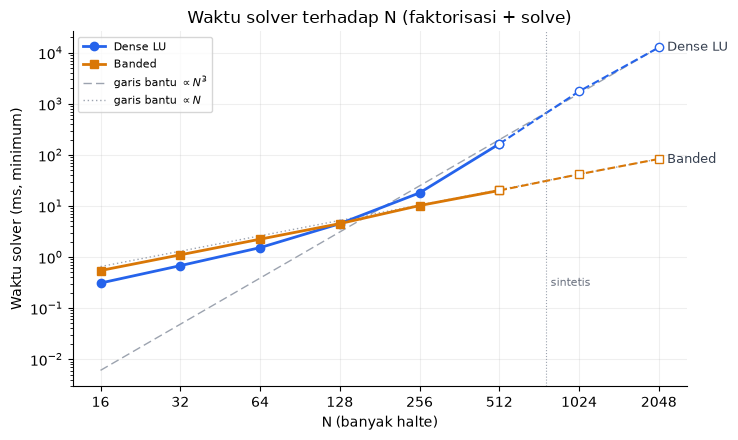

In [109]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
plot_dua_solver(ax, 'solver_dense_s', 'solver_band_s', 1e3, 'Waktu solver (ms, minimum)')
akhir = df_bench_semua.iloc[-1]
garis_referensi(ax, akhir['N'], akhir['solver_dense_s'] * 1e3, 3, r'$\propto N^3$', (0, (6, 3)))
garis_referensi(ax, akhir['N'], akhir['solver_band_s'] * 1e3, 1, r'$\propto N$', (0, (1, 2)))
ax.set_title('Waktu solver terhadap N (faktorisasi + solve)')
ax.legend(loc='upper left', fontsize=8)
fig.tight_layout()
fig.savefig(HASIL / 'waktu_vs_N.png', dpi=200)
plt.show()

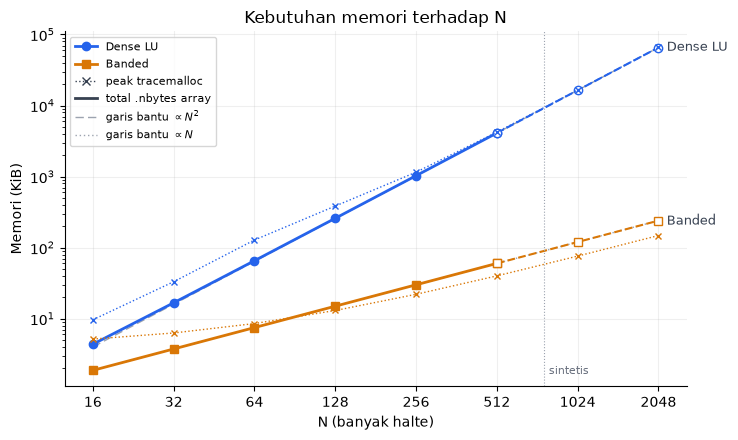

In [110]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
plot_dua_solver(ax, 'nbytes_dense', 'nbytes_band', 1 / 1024, 'Memori (KiB)')
for kolom, warna in (('peak_dense_byte', WARNA_DENSE), ('peak_band_byte', WARNA_BAND)):
    ax.plot(df_bench_semua['N'], df_bench_semua[kolom] / 1024, color=warna, linewidth=1, linestyle=':',
            marker='x', markersize=5)
ax.plot([], [], color='#374151', linewidth=1, linestyle=':', marker='x', label='peak tracemalloc')
ax.plot([], [], color='#374151', linewidth=2, label='total .nbytes array')
akhir = df_bench_semua.iloc[-1]
garis_referensi(ax, akhir['N'], akhir['nbytes_dense'] / 1024, 2, r'$\propto N^2$', (0, (6, 3)))
garis_referensi(ax, akhir['N'], akhir['nbytes_band'] / 1024, 1, r'$\propto N$', (0, (1, 2)))
ax.set_title('Kebutuhan memori terhadap N')
ax.legend(loc='upper left', fontsize=8)
fig.tight_layout()
fig.savefig(HASIL / 'memori_vs_N.png', dpi=200)
plt.show()

Untuk $N \lt 128$ kedua solver setara; solver banded sedikit lebih lambat karena setiap langkahnya berupa loop
Python kecil, sedangkan solver dense memakai operasi vektor NumPy. Mulai $N = 128$ solver banded lebih cepat
(beberapa kali lipat pada $N = 512$ dan lebih dari 100× pada $N = 2048$ sintetis). Memori array dense sekitar 68× memori
banded pada $N = 512$. Pada $N = 512$, waktu membaca CSV sudah lebih besar dari waktu solver banded.

## vi. Analisis Kompleksitas

In [111]:
# Flop faktorisasi, suku utama saja, konvensi kelas (satu pasangan kali-kurang = 1 flop).
# Substitusi dihitung terpisah: dense ~ N^2 (N^2/2 maju + N^2/2 mundur), banded O(N).
def flop_dense(N: int) -> float:
    return N ** 3 / 3


# Banded dengan partial pivoting: N p (p+q) operasi dan (2p+q+1) N memori.
# (Rumus slide (p+q)^2/4 N adalah versi tanpa pivoting, tidak dihitung di sini.)
def flop_band(N: int, p: int, q: int) -> int:
    return N * p * (p + q)


p, q = 2, 1
KOLOM_FLOP_DENSE = 'flop faktorisasi dense (suku utama)'
KOLOM_FLOP_BAND = 'flop faktorisasi banded (suku utama)'
df_teori = pd.DataFrame({'N': df_bench_semua['N']})
df_teori[KOLOM_FLOP_DENSE] = [flop_dense(int(N)) for N in df_teori['N']]
df_teori[KOLOM_FLOP_BAND] = [flop_band(int(N), p, q) for N in df_teori['N']]
df_teori['rasio_flop'] = df_teori[KOLOM_FLOP_DENSE] / df_teori[KOLOM_FLOP_BAND]
df_teori['memori_teori_dense_byte'] = 8 * df_teori['N'] ** 2                   # array faktor LU
df_teori['memori_teori_band_byte'] = 8 * (2 * p + q + 1) * df_teori['N']       # array faktor AB
df_teori.to_csv(HASIL / 'flop_teori.csv', index=False)
df_teori

,N,flop faktorisasi dense (suku utama),flop faktorisasi banded (suku utama),rasio_flop,memori_teori_dense_byte,memori_teori_band_byte
0,16,1.365333e+03,96,14.222222,2048,768
1,32,1.092267e+04,192,56.888889,8192,1536
2,64,8.738133e+04,384,227.555556,32768,3072
3,128,6.990507e+05,768,910.222222,131072,6144
4,256,5.592405e+06,1536,3640.888889,524288,12288
5,512,4.473924e+07,3072,14563.555556,2097152,24576
6,1024,3.579139e+08,6144,58254.222222,8388608,49152
7,2048,2.863312e+09,12288,233016.888889,33554432,98304


In [112]:
def kemiringan_loglog(x, y) -> float:
    lx, ly = np.log(np.asarray(x, float)), np.log(np.asarray(y, float))
    return float(np.sum((lx - lx.mean()) * (ly - ly.mean())) / np.sum((lx - lx.mean()) ** 2))


rentang = {
    'data N=16..512': df_bench_semua['sumber'] == 'data',
    'data N=128..512': (df_bench_semua['sumber'] == 'data') & (df_bench_semua['N'] >= 128),
    'N=256..2048 (+sintetis)': df_bench_semua['N'] >= 256,
}
besaran = {
    'waktu dense (teori 3)': df_bench_semua['solver_dense_s'],
    'waktu band (teori 1)': df_bench_semua['solver_band_s'],
    'flop faktorisasi dense (teori 3)': df_teori[KOLOM_FLOP_DENSE],
    'flop faktorisasi banded (teori 1)': df_teori[KOLOM_FLOP_BAND],
    'nbytes dense (teori 2)': df_bench_semua['nbytes_dense'],
    'nbytes band (teori 1)': df_bench_semua['nbytes_band'],
    'peak dense (teori 2)': df_bench_semua['peak_dense_byte'],
    'peak band (teori 1)': df_bench_semua['peak_band_byte'],
}
df_kemiringan = pd.DataFrame({
    nama_r: {nama_b: kemiringan_loglog(df_bench_semua['N'][m], y[m]) for nama_b, y in besaran.items()}
    for nama_r, m in rentang.items()
}).round(2)
df_kemiringan.to_csv(HASIL / 'kemiringan_loglog.csv')
df_kemiringan

,data N=16..512,data N=128..512,N=256..2048 (+sintetis)
waktu dense (teori 3),1.74,2.59,3.18
waktu band (teori 1),1.05,1.08,1.02
flop faktorisasi dense (teori 3),3.00,3.00,3.00
flop faktorisasi banded (teori 1),1.00,1.00,1.00
nbytes dense (teori 2),1.98,1.99,2.00
nbytes band (teori 1),1.00,1.00,1.00
peak dense (teori 2),1.74,1.73,1.95
peak band (teori 1),0.59,0.81,0.92


In [113]:
# Rasio waktu saat N digandakan (teori: dense 8x, band 2x)
df_rasio = pd.DataFrame({
    'N': df_bench_semua['N'].iloc[1:].values,
    'rasio_waktu_dense': (df_bench_semua['solver_dense_s'].values[1:] / df_bench_semua['solver_dense_s'].values[:-1]),
    'rasio_waktu_band': (df_bench_semua['solver_band_s'].values[1:] / df_bench_semua['solver_band_s'].values[:-1]),
}).round(2)
df_rasio

,N,rasio_waktu_dense,rasio_waktu_band
0,32,2.19,2.03
1,64,2.25,2.02
2,128,2.95,2.02
3,256,4.01,2.26
4,512,9.10,1.97
5,1024,10.67,2.08
6,2048,7.24,1.99


Hitungan flop dan `.nbytes` mengikuti teori tepat (kemiringan 3 dan 2 untuk dense, 1 untuk banded). Waktu solver
banded linear di semua rentang (kemiringan sekitar 1). Waktu solver dense baru mendekati $N^3$ untuk $N \ge 256$;
pada $N$ kecil biaya tetap per langkah (overhead Python/NumPy) mendominasi sehingga kemiringannya jauh di bawah 3.
Peak `tracemalloc` banded pada $N$ kecil didominasi alokasi kecil berukuran tetap, sehingga kemiringannya < 1.

## vii. Analisis Kondisi dan Galat

In [114]:
U_MESIN = 2.0 ** -53    # unit roundoff presisi ganda (pembulatan ke terdekat); sama dengan ε di dokumentasi


def norma1(M: np.ndarray) -> float:
    '''Norma-1 matriks: jumlah mutlak kolom terbesar.'''
    return float(np.max(np.sum(np.abs(M), axis=0)))


def norma1_vektor(v: np.ndarray) -> float:
    return float(np.sum(np.abs(v)))


def invers_dari_LU(LU: np.ndarray, perm: np.ndarray) -> np.ndarray:
    '''Menyelesaikan B X = I untuk semua kolom sekaligus, dari PB = LU.'''
    N = LU.shape[0]
    Y = np.eye(N)[perm, :]                      # P I
    for i in range(1, N):                       # substitusi maju: L Y = P I
        Y[i, :] -= LU[i, :i] @ Y[:i, :]
    X = np.zeros((N, N))
    for i in range(N - 1, -1, -1):              # substitusi mundur: U X = Y
        X[i, :] = (Y[i, :] - LU[i, i + 1:] @ X[i + 1:, :]) / LU[i, i]
    return X


def bilangan_kondisi_1(B: np.ndarray, LU: np.ndarray, perm: np.ndarray) -> float:
    return norma1(B) * norma1(invers_dari_LU(LU, perm))

#### Uji 1: Matriks 3x3

In [115]:
LU_uji, perm_uji = lu_dense(B_uji)
B_inv_uji = invers_dari_LU(LU_uji, perm_uji)
B_inv_tangan = np.array([[1.5, -0.5, 0.0], [-3.0, 2.5, -0.5], [1.0, -1.5, 0.5]])

print('invers sama dengan hitungan tangan :', np.allclose(B_inv_uji, B_inv_tangan, atol=1e-14))
print('max |B B^-1 - I|                   :', np.max(np.abs(B_uji @ B_inv_uji - np.eye(3))))
print('kappa_1 =', norma1(B_uji) * norma1(B_inv_uji), ' (harapan 77)')

invers sama dengan hitungan tangan : True
max |B B^-1 - I|                   : 7.771561172376096e-16
kappa_1 = 77.0  (harapan 77)


#### Pengujian terhadap seluruh dataset

In [116]:
def solusi_z_dense(T: np.ndarray):
    B, b = bentuk_B_dense(T)
    LU, perm = lu_dense(B)
    return B, b, LU, perm, solve_lu(LU, perm, b)


def solusi_z_band(T: np.ndarray) -> np.ndarray:
    p, q = deteksi_bandwidth_T(T)
    AB, b = bentuk_B_band(T, p, q)
    AB_lu, piv = lu_band(AB, p, q)
    return solve_band(AB_lu, piv, p, q, b)


def residual_relatif_B(B, b, z) -> float:
    '''Galat mundur normwise: ||b - Bz||_1 / (||B||_1 ||z||_1).'''
    return norma1_vektor(b - B @ z) / (norma1(B) * norma1_vektor(z))

In [117]:
T_semua = {**T_all, **T_sin}      # hapus T_sin bila tidak ingin N = 1024, 2048
baris = []
for N, T in T_semua.items():
    B, b, LU, perm, z_d = solusi_z_dense(T)
    z_b = solusi_z_band(T)
    pi_d, pi_b = z_d / np.sum(z_d), z_b / np.sum(z_b)

    kappa = bilangan_kondisi_1(B, LU, perm)
    r_d, e_d = galat_pi(T, pi_d)
    r_b, e_b = galat_pi(T, pi_b)
    baris.append({
        'N': N, 'sumber': 'data' if N in N_LIST else 'sintetis',
        'kappa1_B': kappa,
        'r_dense': r_d, 'r_band': r_b,
        'r_rel_dense': r_d / norma2(pi_d),
        'e_norm_dense': e_d, 'e_norm_band': e_b,
        'res_B_dense': residual_relatif_B(B, b, z_d),
        'res_B_band': residual_relatif_B(B, b, z_b),
        'selisih_dense_band': float(np.max(np.abs(pi_d - pi_b))),
        'batas_kappa_u': kappa * U_MESIN,       # lihat bagian 2
    })

df_kondisi = pd.DataFrame(baris)
df_kondisi.to_csv(HASIL / 'kondisi_galat.csv', index=False)
df_kondisi

,N,sumber,kappa1_B,r_dense,r_band,r_rel_dense,e_norm_dense,e_norm_band,res_B_dense,res_B_band,selisih_dense_band,batas_kappa_u
0,16,data,1.677626e+03,1.551584e-17,1.551584e-17,6.074723e-17,0.0,0.0,1.309556e-17,1.309556e-17,0.0,1.862539e-13
1,32,data,6.517531e+03,1.298148e-17,1.298148e-17,7.210873e-17,0.0,0.0,1.061116e-17,1.061116e-17,0.0,7.235913e-13
2,64,data,2.569339e+04,9.658532e-18,9.658532e-18,7.598642e-17,0.0,0.0,1.087981e-17,1.087981e-17,0.0,2.852540e-12
3,128,data,1.020293e+05,5.946332e-18,5.946332e-18,6.620633e-17,0.0,0.0,1.291306e-17,1.291306e-17,0.0,1.132752e-11
4,256,data,1.708794e+09,3.854640e-18,3.854640e-18,6.071572e-17,0.0,0.0,9.878103e-18,9.878103e-18,0.0,1.897142e-07
5,512,data,1.623600e+06,3.208945e-18,3.208945e-18,7.149406e-17,0.0,0.0,1.105143e-17,1.105143e-17,0.0,1.802558e-10
6,1024,sintetis,5.362221e+06,4.185751e-17,4.185751e-17,1.339403e-15,0.0,0.0,1.024448e-17,1.024448e-17,0.0,5.953261e-10
7,2048,sintetis,2.145986e+07,4.174636e-17,4.174636e-17,1.889199e-15,0.0,0.0,1.118569e-17,1.118569e-17,0.0,2.382523e-09


Pada $N = 256$, $\kappa_1(B) \approx 1{,}7\cdot10^{9}$, jauh lebih besar daripada ukuran lain, karena peluang pindah
antara halte 128 dan 129 hanya berorde $10^{-8}$ (lihat i.b). Residual $r$ tetap sekitar $4\cdot10^{-18}$, tetapi galat
maju eksak mencapai $5{,}8\cdot10^{-11}$, sekitar $6\cdot10^{-4}$ dari indikator $\kappa u$. Jadi residual kecil tidak
menjamin galat maju kecil, dan galat maju tumbuh mengikuti $\kappa$. Solver dense dan banded memberi galat yang sama
karena kedua solver melakukan operasi yang sama (tidak ada pertukaran baris).

In [118]:
from fractions import Fraction


def residual_eksak(B, b, z_frac, p, q):
    '''rho = b - B z dihitung eksak (rasional); B band dengan bandwidth (p, q).'''
    N = len(b)
    rho = []
    for i in range(N):
        s = Fraction(float(b[i]))
        for j in range(max(0, i - p), min(N - 1, i + q) + 1):
            s -= Fraction(float(B[i, j])) * z_frac[j]
        rho.append(s)
    return rho


def perbaiki_iteratif_eksak(B, b, LU, perm, z, p, q, iterasi: int = 4):
    z_frac = [Fraction(float(v)) for v in z]
    for _ in range(iterasi):
        rho = residual_eksak(B, b, z_frac, p, q)
        d = solve_lu(LU, perm, np.array([float(v) for v in rho]))
        z_frac = [zf + Fraction(float(dv)) for zf, dv in zip(z_frac, d)]
    return z_frac


def galat_maju_eksak(pi, z_acuan_frac) -> float:
    s = sum(z_acuan_frac)
    pi_acuan = [zf / s for zf in z_acuan_frac]
    selisih = sum(abs(Fraction(float(pf)) - pr) for pf, pr in zip(pi, pi_acuan))
    return float(selisih)          # sum(pi_acuan) = 1, jadi ini galat relatif norma-1


baris = []
for N, T in T_semua.items():
    B, b, LU, perm, z_d = solusi_z_dense(T)
    z_b = solusi_z_band(T)
    p, q = deteksi_bandwidth(B)
    z_acuan = perbaiki_iteratif_eksak(B, b, LU, perm, z_d, p, q)
    baris.append({
        'N': N,
        'galat_eksak_dense': galat_maju_eksak(z_d / np.sum(z_d), z_acuan),
        'galat_eksak_band': galat_maju_eksak(z_b / np.sum(z_b), z_acuan),
    })

df_eksak = pd.DataFrame(baris)
df_kondisi = df_kondisi.merge(df_eksak, on='N')
df_kondisi['rasio_eksak_per_batas'] = df_kondisi['galat_eksak_dense'] / df_kondisi['batas_kappa_u']
df_kondisi.to_csv(HASIL / 'kondisi_galat.csv', index=False)
df_kondisi[['N', 'kappa1_B', 'galat_eksak_dense', 'galat_eksak_band', 'rasio_eksak_per_batas']]

,N,kappa1_B,galat_eksak_dense,galat_eksak_band,rasio_eksak_per_batas
0,16,1.677626e+03,4.239467e-16,4.239467e-16,0.002276
1,32,6.517531e+03,8.020925e-16,8.020925e-16,0.001108
2,64,2.569339e+04,1.086218e-14,1.086218e-14,0.003808
3,128,1.020293e+05,1.573986e-14,1.573986e-14,0.001390
4,256,1.708794e+09,5.752275e-11,5.752275e-11,0.000303
5,512,1.623600e+06,8.640632e-14,8.640632e-14,0.000479
6,1024,5.362221e+06,4.654038e-13,4.654038e-13,0.000782
7,2048,2.145986e+07,2.026287e-13,2.026287e-13,0.000085


## viii. Interpretasi Hasil

In [119]:
def ringkas_pi(pi: np.ndarray) -> dict:
    N = len(pi)
    i_maks, i_min = int(np.argmax(pi)), int(np.argmin(pi))
    dekat = np.nonzero(pi >= 0.99 * pi[i_maks])[0] + 1      # halte dalam 1% dari maksimum
    return {
        'N': N,
        'halte_maks': i_maks + 1, 'pi_maks': float(pi[i_maks]), 'N_pi_maks': float(N * pi[i_maks]),
        'halte_min': i_min + 1, 'pi_min': float(pi[i_min]), 'N_pi_min': float(N * pi[i_min]),
        'halte_dekat_maks': f'{dekat.min()}-{dekat.max()} ({len(dekat)} halte)',
    }


assert all(np.allclose(pi_band[N], pi_dense[N], rtol=0, atol=1e-9) for N in N_LIST)
assert all(abs(float(np.sum(pi_band[N])) - 1.0) < 1e-12 and pi_band[N].min() > 0 for N in N_LIST)

df_interpretasi = pd.DataFrame([ringkas_pi(pi_band[N]) for N in N_LIST])
df_interpretasi['waktu_kembali_maks'] = 1.0 / df_interpretasi['pi_maks']
df_interpretasi.to_csv(HASIL / 'interpretasi_pi.csv', index=False)
df_interpretasi

,N,halte_maks,pi_maks,N_pi_maks,halte_min,pi_min,N_pi_min,halte_dekat_maks,waktu_kembali_maks
0,16,16,0.095963,1.535409,1,0.039016,0.624251,16-16 (1 halte),10.420678
1,32,32,0.048136,1.540341,1,0.019570,0.626256,32-32 (1 halte),20.774624
2,64,64,0.024103,1.542610,1,0.009800,0.627178,64-64 (1 halte),41.488126
3,128,128,0.012060,1.543698,1,0.004903,0.627621,128-128 (1 halte),82.917772
4,256,256,0.006032,1.544231,1,0.002452,0.627837,255-256 (2 halte),165.778349
5,512,512,0.003017,1.544494,1,0.001226,0.627944,510-512 (3 halte),331.500137


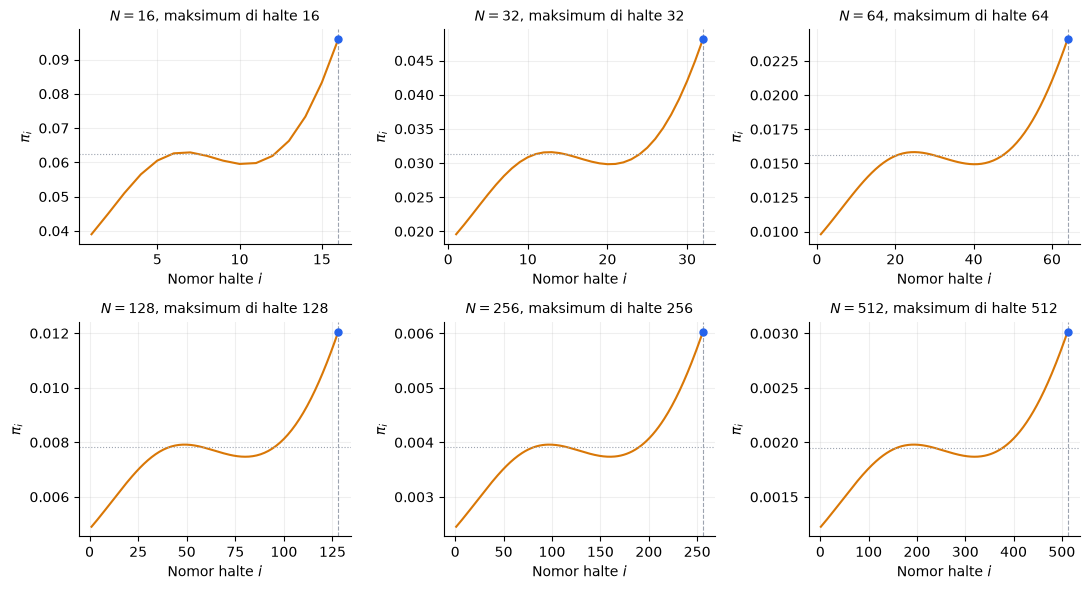

In [120]:
fig, sumbu = plt.subplots(2, 3, figsize=(11, 6))
for ax, N in zip(sumbu.ravel(), N_LIST):
    pi = pi_band[N]
    halte = np.arange(1, N + 1)
    i_maks = int(np.argmax(pi))
    ax.plot(halte, pi, color=WARNA_BAND, linewidth=1.5)
    ax.axhline(1.0 / N, color=WARNA_REF, linewidth=0.8, linestyle=':')            # distribusi seragam 1/N
    ax.axvline(i_maks + 1, color=WARNA_REF, linewidth=0.8, linestyle='--')
    ax.plot(i_maks + 1, pi[i_maks], 'o', color=WARNA_DENSE, markersize=5)
    ax.set_title(f'$N={N}$, maksimum di halte {i_maks + 1}', fontsize=10)
    ax.set_xlabel('Nomor halte $i$')
    ax.set_ylabel(r'$\pi_i$')
    ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(HASIL / 'pi_vs_halte.png', dpi=200)
plt.show()

max |pi_i (1 - T_ii) - arus_masuk_i| = 1.6263032587282567e-18
korelasi(pi, 1/keluar)               = 0.03494693586056404


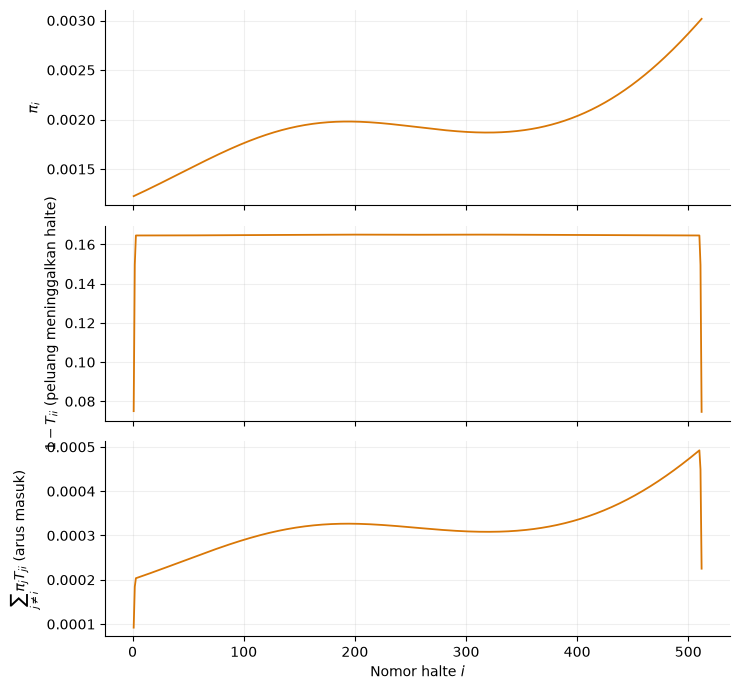

In [121]:
N_DIAG = 512
T, pi = T_all[N_DIAG], pi_band[N_DIAG]
keluar = 1.0 - np.diag(T)                         # peluang meninggalkan halte i
arus_masuk = T.T @ pi - np.diag(T) * pi           # sum_{j != i} pi_j T_ji
print('max |pi_i (1 - T_ii) - arus_masuk_i| =', np.max(np.abs(pi * keluar - arus_masuk)))
print('korelasi(pi, 1/keluar)               =', np.corrcoef(pi, 1.0 / keluar)[0, 1])

halte = np.arange(1, N_DIAG + 1)
fig, sumbu = plt.subplots(3, 1, figsize=(7.5, 7), sharex=True)
for ax, y, label in zip(sumbu, (pi, keluar, arus_masuk),
                        (r'$\pi_i$', r'$1-T_{ii}$ (peluang meninggalkan halte)',
                         r'$\sum_{j\ne i}\pi_jT_{ji}$ (arus masuk)')):
    ax.plot(halte, y, color=WARNA_BAND, linewidth=1.3)
    ax.set_ylabel(label)
    ax.grid(alpha=0.2)
sumbu[-1].set_xlabel('Nomor halte $i$')
fig.tight_layout()
fig.savefig(HASIL / 'pi_dan_arus.png', dpi=200)
plt.show()

In [122]:
pi256 = pi_band[256]
print('pi_126..131 =', pi256[125:131])
print('pi_129 / pi_128 =', pi256[128] / pi256[127])

pi_126..131 = [0.0039 0.0039 0.0038 0.0038 0.0038 0.0038]
pi_129 / pi_128 = 0.9986025255791178


Meskipun $\kappa_1(B)$ sangat besar pada $N = 256$, $\pi$ hampir mulus di sambungan halte 128/129
($\pi_{129}/\pi_{128} = 0{,}9986$). Kondisi buruk berarti $\pi$ sensitif terhadap gangguan pada $T$ dan pembulatan,
bukan berarti hasilnya tampak cacat pada plot.

drift halte 1..8      : [0.09   0.0153 0.0004 0.0004 0.0004 0.0004 0.0004 0.0004]
drift halte 505..512  : [ 0.0004  0.0004  0.0004  0.0004  0.0004  0.0004 -0.0296 -0.0746]
maks |drift| halte 100..412: 0.0002757652976015379


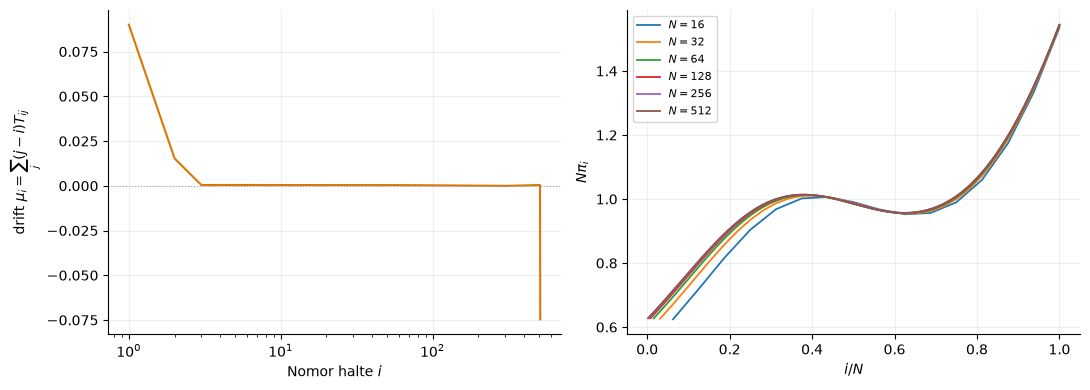

In [123]:
def drift(T):
    idx = np.arange(T.shape[0])
    return T @ idx - idx                      # mu_i = sum_j (j - i) T_ij

mu = drift(T_all[512])
print('drift halte 1..8      :', mu[:8])
print('drift halte 505..512  :', mu[-8:])
print('maks |drift| halte 100..412:', np.max(np.abs(mu[99:412])))

fig, sumbu = plt.subplots(1, 2, figsize=(11, 4))
sumbu[0].plot(np.arange(1, 513), mu, color=WARNA_BAND)
sumbu[0].axhline(0, color=WARNA_REF, linewidth=0.8, linestyle=':')
sumbu[0].set(xlabel='Nomor halte $i$', ylabel=r'drift $\mu_i=\sum_j (j-i)T_{ij}$', xscale='log')
for N in N_LIST:
    sumbu[1].plot(np.arange(1, N + 1) / N, N * pi_band[N], label=f'$N={N}$', linewidth=1.3)
sumbu[1].set(xlabel='$i/N$', ylabel=r'$N\pi_i$')
sumbu[1].legend(fontsize=8)
for ax in sumbu:
    ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(HASIL / 'drift_dan_profil.png', dpi=200)
plt.show()

In [124]:
for kol in ('N_pi_maks', 'N_pi_min'):
    v = df_interpretasi[kol].to_numpy()
    print(kol, 'ekstrapolasi 2v(2N)-v(N):', np.round(2 * v[1:] - v[:-1], 4))

N_pi_maks ekstrapolasi 2v(2N)-v(N): [1.5453 1.5449 1.5448 1.5448 1.5448]
N_pi_min ekstrapolasi 2v(2N)-v(N): [0.6283 0.6281 0.6281 0.6281 0.6281]


Nilai $N\pi_{\max}$ naik dari 1,535 ($N=16$) ke 1,544 ($N=512$), dan $N\pi_{\min}$ dari 0,624 ke 0,628. Selisih antar ukuran berturut-turut selalu setengahnya, sehingga galatnya $O(1/N)$ dan ekstrapolasi menunjuk ke sekitar 1,545 dan 0,628. Bentuk $\pi$ karena itu hanya bergantung pada posisi relatif $i/N$, dan halte terakhir selalu memiliki proporsi terbesar, sekitar 1,54 kali proporsi seragam $1/N$.